<center>
    <h1>OCES 5303</h1>
    <h2>Assignment 1</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h5>Abstract</h5>
    <p>
    Argo is an international program collecting data from the global ocean at various depths using robotic instruments drifting with ocean currents
    <small style="margin-left: 1em">[1]</small>
    </p>
    <p>
    In this assignemnt, we will explore the dataset, and perform linear regression  to see if we can predict the sea temperature.
    </p>
    <img src="../figures/cover.jpg" width="50%">
</center>

<h1>The Data</h1>

<p>
The standard mission for Argo's robotic instruments is what's known as "park-and-profile".
</p>
<p>
It involves the robotic instrument, the "float", descending to a depth of approximatly 1,000 km (10,000 Pa) and
drifting with the ocean currents. Then, every 10 days, the float descents to 2,000 km (20,000 Pa) and starts its data collection.
It collects data on its accent back up to the surface at various depths, taking around six hours to complete.
At the surface, the float transmits the data collected over satelitte.
</p>
<p>
Most of the floats record the temperature and the salinity of the water, and some also collect information on properties describing the biology/chemistry of the water.
In this report, we'll only look at the temperature and the salinity at various depths.
</p>
<small style="margin-left: 1em">[2] [3]</small>

In [2]:
#####################################
#       You might need to restart   #
#           the kernel after        #
#           running this cell.      #
#####################################

## Downloads

# %pip install -r ./requirements.txt

In [19]:
## Imports

import xarray as xr
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from plotly.subplots import make_subplots
from sklearn import set_config
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer, FunctionTransformer, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, PredictionErrorDisplay
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import DBSCAN, KMeans
from sklearn.inspection import DecisionBoundaryDisplay

## Configuration

set_config(transform_output = "pandas")
pio.templates.default = "plotly_dark"
seed = 1337

<h1>Parsing</h1>

<p>
We have six different variables, described in their attributes as:
</p>

<ul>
    <li><code>DEPTH</code>: Vertical Distance Below the Surface (m)</li>
    <li><code>PSAL</code>: Practical Salinity (PSU)</li>
    <li><code>TEMP</code>: Sea Temperature In-Situ ITS-90 Scale (℃)</li>
    <li><code>TIME</code>: Time of Measurement</li>
    <li><code>LATITUDE</code>: Latitude (degrees north)</li>
    <li><code>LONGITUDE</code>: Longitude (degrees east)</li>
</ul>

<p>
Here, we'll only look at data from the Atlantic Ocean, so we can remove rows with latitude and longitude outside <code>(-75, 17)</code>. In addition, we remove rows where the salinity range falls outside reasonable values.
</p>

In [5]:
## Read and process data

ds = xr.open_zarr("../data/GLOB_HOMOGENEOUS_variables.zarr/", consolidated=False)
da_al = ds[["PSAL", "TEMP", "DEPTH"]] # (DEPTH: 302, N_PROF: 128910)
da_s  = da_al.where(((da_al.PSAL < 40.) & (da_al.PSAL > 25.)).compute(), drop=True) # Remove rows outside reasonable salinity range
da_s  = da_s.dropna('N_PROF')
da = da_s.where((da_s['LONGITUDE'] > -75.) & (da_s['LONGITUDE'] < 17), drop= True) # Atlantic ocean

df = da.to_dataframe().reset_index()
df["TIME"] = df["TIME"].to_numpy(float) # Convert to float (TODO: consider scaling)
df["LATITUDE"] = df["LATITUDE"].to_numpy(float)
df["LONGITUDE"] = df["LONGITUDE"].to_numpy(float)

<h1>Exploratory Data Analysis</h1>

<p>Now, let's explore the data to see if we can find any outliers, trends, etc. Let's start by plotting some of the geographical points in our dataset.</p>

In [6]:
## Select subset of data

df_geo_subset = df.sample(200, random_state=seed)

## Scale subset of data to visualize

scalar = MinMaxScaler() # TODO: Consider other scalar
df_geo_subset["TEMP_S"] = scalar.fit_transform(df_geo_subset["TEMP"].values.reshape(-1, 1)).values
df_geo_subset["PSAL_S"] = scalar.fit_transform(df_geo_subset["PSAL"].values.reshape(-1, 1)).values

## Create figures

fig_geo_temp = px.scatter_geo(df_geo_subset, lat="LATITUDE", lon="LONGITUDE", color="TEMP_S", hover_name="TEMP")
fig_geo_psal = px.scatter_geo(df_geo_subset, lat="LATITUDE", lon="LONGITUDE", color="PSAL_S", hover_name="PSAL")

fig_geo = make_subplots(rows=1, cols=2, specs=[[{'type': 'geo'}, {'type': 'geo'}]], subplot_titles=("Temperature (scaled)", "Salinity (scaled)"))
for trace in fig_geo_temp.data: fig_geo.add_trace(trace, row=1, col=1)
for trace in fig_geo_psal.data: fig_geo.add_trace(trace, row=1, col=2)

fig_geo.update_layout(height=450, title_text="Locations of floats and their data", coloraxis_colorbar=dict(orientation="h", y=-0.2, yanchor="bottom", x=0.5, xanchor="center"), coloraxis=dict(colorscale="Plasma"))
fig_geo.show()

<p>
We see that our attempt at only selecting data from the Atlantic Ocean has failed, and we have some outliers in the Pacific Ocean.
</p>

<p>
These might interfere with our results, due to natural phenomenons such as ENSO (causing sea surface temperature differences in the Pacific Ocean). Let's remove any observations made with a longitude smaller than <code>-60.0</code> if the latitude is also smaller than <code>7.0</code>. In reality, our geographical restrictions aren't a perfect description of the Pacific Ocean, but for our data, it's good enough.
</p>

<small style="margin-left: 1em">[5]</small>

In [7]:
## Remove geographical outliers

df = df[(df["LATITUDE"] >= 7.0) | (df["LONGITUDE"] >= -60.0)]

<p>
We can also see that we have some observations with very large values, e.g. temperature observations of around 25 ℃ (although often correlated with high salinity). We should consider removing these outliers later.
</p>

<h2>Split Data</h2>

<p>
Let's also split the data up into three different data sets: training, validation and testing. We do this to avoid any biases in our training, and minimize overfitting. Let's also drop the <code>N_PROF</code> variable, since this is essentialy an identification variable for each profile - and won't generalize for new Argo data.
</p>

In [8]:
## Split data (70%, 15%, 15%)

X = df.drop(columns = ["N_PROF", "TEMP"])
y = df["TEMP"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, train_size = 0.7, random_state = seed)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, train_size = 0.5, test_size = 0.5, random_state = seed)

## Combined train set (for visualization)

Xy_train = pd.concat([X_train, y_train], axis=1)

<h2>Trends</h2>

<p>
Now, let's see if we can see any obvious trends between our features and our target variables.
</p>

In [9]:
feature_names = X_train.columns
df_data_subset = Xy_train.sample(int(420 * 2), random_state=seed)
fig_trends = make_subplots(rows=len(feature_names), cols=1, subplot_titles=list(map(lambda v: f"{v} vs. TEMP", feature_names)))

for (i, feat) in enumerate(feature_names):
    fig_trend = px.scatter(df_data_subset, x=feat, y="TEMP", color="TEMP", trendline="ols")
    fig_trend.update_traces(line={"color": "orange", "width": 2, "dash": "dot"})
    for trace in fig_trend.data: fig_trends.add_trace(trace, row=(i + 1), col=1)

fig_trends.update_layout(height=1500, coloraxis_showscale=False, coloraxis=dict(colorscale="Plasma"))
fig_trends.show()

<p>
We see that <code>PSAL</code> is the feature with the strongest correlation to <code>TEMP</code>. In addition, <code>DEPTH</code> seems to be correlated to <code>TEMP</code> for lower values (which of course makes sense). The <code>LATITUDE</code> also seems to be a good predictor for lower temperatures, when the latitude is less than approx. <code>-50</code> or greater than approx. <code>50</code> (i.e. close to the polar circles).
</p>

<h1>Metrics</h1>

<p>
Let's define a function that prints various metrics for each model we train.
</p>

In [10]:
def metrics(model, visualize=True):
    out = dict({
        "Mean Absolute Error": mean_absolute_error(y_val, model.predict(X_val)),
        "Mean Squared Error": np.sqrt(mean_squared_error(y_val, model.predict(X_val))),
        "R2": r2_score(y_val, model.predict(X_val))
    })

    for k, v in out.items():
        print(f"{k}: {v:.5f}")

    # TODO: Consider re-creating in Plotly Express
    if (visualize): return PredictionErrorDisplay.from_estimator(model, X_val, y_val)

<h1>Baseline Model</h1>

<p>
Now, we'll train a baseline model so we have something to compare our models against.
The baseline model will simply calculate the mean of our target variable.
</p>

In [11]:
## Train baseline model

r_dummy = DummyRegressor()
r_dummy = r_dummy.fit(X_train, y_train)

## Visualize

_ = metrics(r_dummy, False)

Mean Absolute Error: 4.30821
Mean Squared Error: 5.48604
R2: 0.00000


<h1>Linear Regression</h1>

<p>
Let's see if linear regression performs any better.
</p>

In [12]:
## Train linear regression model

r_linear = LinearRegression()
r_linear = r_linear.fit(X_train, y_train)

## Visualize

_ = metrics(r_linear, False)

Mean Absolute Error: 4.30818
Mean Squared Error: 5.48570
R2: 0.00012


<p>
Perhaps a bit suprisingly, the linear regression struggles to find any relationship between the features and the target variable, and our performance results are almost identical to our <code>DummyRegressor</code>.
</p>

<p>
We should perhaps consider feature selection, clustering, scaling, and other machine learning methods to improve our model.
</p>

<p>
But first, let's try a few other models.
</p>

<h1>Ridge Regression</h1>

<p>
This regression model also uses least squares, but includes L2 regularization.
</p>

In [13]:
## Train logistic regression model

r_ridge = Ridge(random_state=seed)
r_ridge = r_ridge.fit(X_train, y_train)

## Visualize

metrics(r_ridge, False)

Mean Absolute Error: 1.62245
Mean Squared Error: 2.30685
R2: 0.82318


/usr/local/conda/envs/OCES5303/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6302349938482227e-35.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


<h1>Random Forest Regression</h1>

In [14]:
## Train random forest regression model

r_randomforest = RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1, random_state=seed)
r_randomforest = r_randomforest.fit(X_train, y_train)

## Visualize

metrics(r_randomforest, False)

Mean Absolute Error: 0.88666
Mean Squared Error: 1.35961
R2: 0.93858


<h1>Feature Selection & Scaling Features</h1>

<p>
One reason that we might be seeing better results using random forest regression, is that it's scale-invariant. Unlike ridge regression, where scaling of the features yields different results, random forest's node based are not affected by scaled features, since the decision nodes will just scale with the features.
</p>

<p>
In addition, we have so far trained our regression models with all the available features. But, features like <code>LATITUDE</code> and <code>LONGITUDE</code>, are high-cardinality features. They are variables used to describe the location of where a measurement was made, but a machine learning model might struggle to generalize this data to new unseen data, since it's specific to each data point.
</p>

<p>
Lastly, the <code>N_PROF</code> feature is an identifier for each data point, which will also make it hard for machine learning models to generalize for unseen data.
</p>

<p>
We'll create a pipeline that removes these features, scales the other features appropriately, and tests different machine learning models.
</p>

In [ ]:
pipeline = Pipeline([
    ("remove_features", ColumnTransformer([("remove_features", "drop", ["N_PROF", "LATITUDE", "LONGITUDE"])], remainder="passthrough", verbose_feature_names_out = False)),
    ("scale_standard", ColumnTransformer([("scale_standard", StandardScaler(), [])], remainder="passthrough", verbose_feature_names_out=False)),
    ("scale_minmax", ColumnTransformer([("scale_minmax", MinMaxScaler(), [])], remainder="passthrough", verbose_feature_names_out=False)),
    ("scale_quantile", ColumnTransformer([("scale_minmax", QuantileTransformer(random_state=seed), [])], remainder="passthrough", verbose_feature_names_out=False)),
    ("regression", Ridge(random_state = seed))
])

pipeline.fit(X_train, y_train)

metrics(pipeline, False)

# 1.62251
# 2.30666

Mean Absolute Error: 1.62245
Mean Squared Error: 2.30685
R2: 0.82318


/usr/local/conda/envs/OCES5303/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6302349938482227e-35.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


<h1>Clustering</h1>

In [16]:
## Pick data subset

df_data_subset = Xy_train.sample(int(420 * 2), random_state=seed)
feature_names = ["LATITUDE", "LONGITUDE", "DEPTH", "PSAL"]

## Create figure

fig_clusters = make_subplots(rows=len(feature_names), cols=1, subplot_titles=list(map(lambda v: f"{v} cluster", feature_names)))

for (i, feat) in enumerate(feature_names):
    ## Find clusters

    c_kmeans = KMeans(n_clusters=8, random_state=seed)
    df_data_subset[f"{feat}_CLUSTER"] = c_kmeans.fit_predict(df_data_subset[[feat]])

    ## Add to figure

    fig_cluster = px.scatter(df_data_subset, x=feat, y="TEMP", color=f"{feat}_CLUSTER", trendline="ols")
    fig_cluster.update_traces(line={"color": "orange", "width": 2, "dash": "dot"})
    for trace in fig_cluster.data: fig_clusters.add_trace(trace, row=(i + 1), col=1)

## Show scatter plots with cluster zones

fig_clusters.update_layout(height=1500, coloraxis_showscale=False, coloraxis=dict(colorscale="Plasma"))
fig_clusters.show()

<p>
We see that for <code>LATITUDE</code>, the first and last cluster have less variation, and they seem to be good predictors for lower temperatures (or at least that the temperatures are below the trendline for ordinary least squares regression). This is of course something that could have been picked up by our models, but we'll add this information as an extra column to see if it improves our predictions.
</p>

<p>
But first, let's see if we can find any clusters between <code>LATITUDE</code> and <code>LONGITUDE</code> to see if that's perhaps a good predictor for <code>TEMP</code>. Let's also try between <code>DEPTH</code> and <code>PSAL</code>. We'll also standardize the values before attempting to find clusters (since <code>DEPTH</code> and <code>PSAL</code> are using different scales).
</p>


In [17]:
## Pick data subset

df_data_subset = Xy_train.sample(int(420 * 2), random_state=seed)
feature_names = [["LATITUDE", "LONGITUDE"], ["DEPTH", "PSAL"]]

for (i, [feat_1, feat_2]) in enumerate(feature_names):
    ## Scale
    df_data_subset[feat_1] = StandardScaler().fit_transform(df_data_subset[[feat_1]])
    df_data_subset[feat_2] = StandardScaler().fit_transform(df_data_subset[[feat_2]])

    ## Find clusters

    c_kmeans = KMeans(n_clusters=6, random_state=seed)
    df_data_subset[f"{feat_1}_{feat_2}_CLUSTER"] = c_kmeans.fit_predict(df_data_subset[[feat_1, feat_2]])

    ## Show 3D scatter plots with cluster zones

    fig_cluster = px.scatter_3d(df_data_subset, x=feat_1, y=feat_2, z="TEMP", color=f"{feat_1}_{feat_2}_CLUSTER")
    fig_cluster.update_layout(coloraxis_showscale=False, coloraxis=dict(colorscale="Plasma"))
    fig_cluster.show()

<p>
The first plot doesn't seem to have any obvious patterns that are not also present in the clusters for <code>LATITUDE</code>. But, the second plot shows a clear relationship between <code>DEPTH</code> and <code>PSAL</code> and its effect on the temperature.
</p>

<p>
Let's create two transformers that'll add these features.
</p>

In [ ]:
# K-Means LATITUDE

c_kmeans_latitude = KMeans(n_clusters=8, random_state=seed)
c_kmeans_latitude = c_kmeans_latitude.fit(X_train[["LATITUDE"]].map(lambda v: np.double(v)))

# K-Means DEPTH/PSAL

_c_kmeans_depth_psal_scalar = StandardScaler().fit(X_train[["DEPTH", "PSAL"]])
c_kmeans_depth_psal = KMeans(n_clusters=6, random_state=seed)
c_kmeans_depth_psal = c_kmeans_depth_psal.fit(_c_kmeans_depth_psal_scalar.transform(X_train[["DEPTH", "PSAL"]]))

## LATITUDE_CLUSTER

def _add_clusters_latitude(data):
    data_c = data.copy()
    X_c = data[["LATITUDE"]].map(lambda v: np.double(v))
    data_c["CL"] = c_kmeans_latitude.predict(X_c)

    return data_c

def _remove_latitude(data):
    data_c = data.copy()
    data_c = data_c.drop(columns=["LATITUDE"])

    return data_c

## DEPTH_PSAL_CLUSTER

def _add_clusters_depth_psal(data):
    data_c = data.copy()
    X_c = _c_kmeans_depth_psal_scalar.transform(data[["DEPTH", "PSAL"]])
    data_c["CDP"] = c_kmeans_depth_psal.predict(X_c)

    return data_c

def _remove_depth_psal(data):
    data_c = data.copy()
    data_c = data_c.drop(columns=["DEPTH", "PSAL"])

    return data_c

## Create (intermediary) cluster transformers

_t_clusters_latitude = FunctionTransformer(func=_add_clusters_latitude)
_t_clusters_depth_psal = FunctionTransformer(func=_add_clusters_depth_psal)

_t_remove_latitude = FunctionTransformer(func=_remove_latitude)
_t_remove_depth_psal = FunctionTransformer(func=_remove_depth_psal)

## Create (intermediary) encoder transformers

_t_clusters_encode_latitude = ColumnTransformer([("clusters_encode_latitude", OneHotEncoder(sparse_output=False), ["CL"])], remainder="passthrough", verbose_feature_names_out=False)
_t_clusters_encode_depth_psal = ColumnTransformer([("clusters_encode_depth_psal", OneHotEncoder(sparse_output=False), ["CDP"])], remainder="passthrough", verbose_feature_names_out=False)

## Create transformers for finding clusters, encoding, and optionally removing features

t_clusters = Pipeline([("1", _t_clusters_latitude), ("2", _t_clusters_depth_psal), ("3", _t_clusters_encode_latitude), ("4", _t_clusters_encode_depth_psal)])
t_clusters_remove_features = Pipeline([("1", _t_remove_latitude), ("2", _t_remove_depth_psal)])

/usr/local/conda/envs/OCES5303/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6880806928000456e-41.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Mean Absolute Error: 0.95074
Mean Squared Error: 1.48147
R2: 0.92708


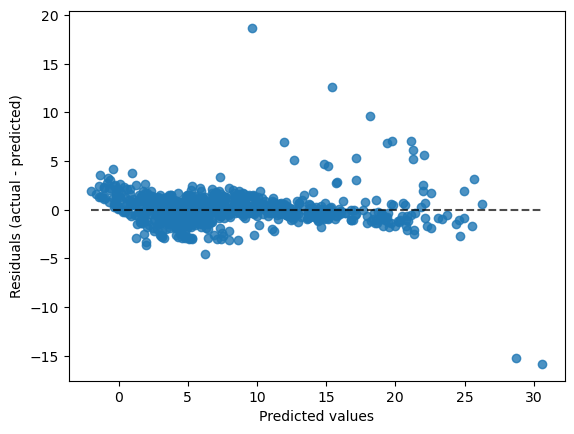

In [ ]:
## Test pipeline. ##

pipeline = Pipeline([
    ("clusters", t_clusters),
    #("remove_latitude", t_clusters_remove_features),
    #("regression", RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1, random_state=seed))
    ("regression", Ridge(random_state=seed))
])

pipeline.fit(X_train, y_train)

_ = metrics(pipeline)

# Mean Absolute Error: 0.87750
# Mean Squared Error: 1.34960

# Mean Absolute Error: 0.88782
# Mean Squared Error: 1.35528
# R2: 0.93897

# Ridge (without clusters):
# Mean Absolute Error: 1.62245
# Mean Squared Error: 2.30685
# R2: 0.82318

# Mean Absolute Error: 0.95074
# Mean Squared Error: 1.48147
# R2: 0.92708

In [ ]:
## Too complicated to visualize. ##

# # Pick data subset

# df_data_subset = Xy_train[["LATITUDE", "LONGITUDE", "DEPTH", "TEMP"]].sample(int(420 * 2), random_state=seed)
# df_data_subset["LATITUDE"] = df_data_subset["LATITUDE"].astype(np.double)
# df_data_subset["LONGITUDE"] = df_data_subset["LONGITUDE"].astype(np.double)
# df_data_subset["DEPTH"] = df_data_subset["DEPTH"].astype(np.double)
# df_data_subset["TEMP"] = np.round(df_data_subset["TEMP"])

# # scalar = MinMaxScaler()
# # df_data_subset = scalar.fit_transform(df_data_subset)

# # Find clusters

# c_kmeans = KMeans(n_clusters=5, random_state=seed)
# df_data_subset["CLUSTER"] = c_kmeans.fit_predict(df_data_subset)
# #df_data_subset["TEMP"] = df_data_subset_temp

# # Show scatter plot with cluster zones

# fig_cluster = px.scatter_3d(df_data_subset, x="LATITUDE", y="LONGITUDE", z="DEPTH", color="TEMP", opacity=0.7)
# #fig_cluster.update_traces(line={"color": "orange", "width": 2, "dash": "dot"})
# fig_cluster.update_traces(marker=dict(size=5), line=dict(width=20, color=df_data_subset["TEMP"]), selector=dict(mode='markers'))
# fig_trends.update_layout(coloraxis_showscale=False, coloraxis=dict(colorscale="Plasma"))

# fig_cluster.show()

In [ ]:
## Did not show any meaningful clusters. ##

# # Pick data subset

# df_data_subset = Xy_train[["LATITUDE", "TEMP"]].sample(int(420 * 2), random_state=seed)
# #df_data_subset_temp = df_data_subset.pop("TEMP")

# # Find clusters

# c_dbscan = DBSCAN(eps=0.9, min_samples=10, n_jobs=-1)
# df_data_subset["CLUSTER"] = c_dbscan.fit_predict(df_data_subset)
# #df_data_subset["TEMP"] = df_data_subset_temp

# # Show scatter plot with cluster zones

# fig_cluster = px.scatter(df_data_subset, x="LATITUDE", y="TEMP", color="CLUSTER", trendline="ols")
# fig_cluster.update_traces(line={"color": "orange", "width": 2, "dash": "dot"})
# fig_trends.update_layout(coloraxis_showscale=False, coloraxis=dict(colorscale="Plasma"))

# fig_cluster.show()

<h1>References</h1>

<p>[1]    Argo. <a href="https://argo.ucsd.edu" target="_blank">https://argo.ucsd.edu</a>. 2026.</p>
<p>[2]    Argo Program Office. <i>About Argo</i>. <a href="https://argo.ucsd.edu/about" target="_blank">https://argo.ucsd.edu/about</a> [Online; accessed 26-Februrary-2026]. 2026.</p>
<p>[3]    Wong, Annie P. S., et. al. <i>Argo Data 1999-2019: Two Million Temperature-Salinity
Profiles and Subsurface Velocity Observations From a Global Array of Profiling Floats</i>. <a href="https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2020.00700" target="_blank">https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2020.00700</a> [Online; accessed 26-Februrary-2026]. 2026.</p>
<p>[4]    Argo (2000). <i>Argo float data and metadata from Global Data Assembly Centre (Argo GDAC)</i>. SEANOE. <a href="http://doi.org/10.17882/42182" target="_blank">http://doi.org/10.17882/42182</a></p>
<p>[5]    Wikipedia contributors (2026). <i>El Niño–Southern Oscillation</i>. Wikipedia, The Free Encyclopedia. <a href="https://en.wikipedia.org/w/index.php?title=El_Ni%C3%B1o%E2%80%93Southern_Oscillation&oldid=1341681100" target="_blank">https://en.wikipedia.org/w/index.php?title=El_Ni%C3%B1o%E2%80%93Southern_Oscillation&oldid=1341681100</a> [Online; accessed 5-March-2026</p>